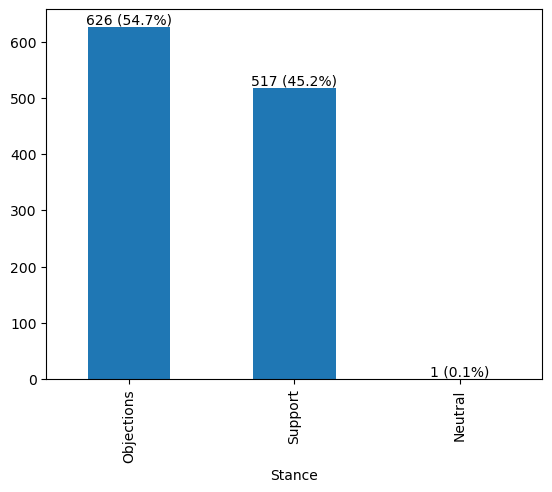

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ollama
import os

data = pd.read_csv(r'C:\Users\mauth\Data Scraping for Vee\final_planning_data1.csv')
# print(data.iloc[0, 4])
stance_counts = data['Stance'].value_counts()
stance_counts = stance_counts.rename({'Customer objects to the Planning Application': 'Objections', 
                                      'Customer made comments in support of the Planning Application': 'Support',
                                     'Customer made comments neither objecting to or supporting the Planning Application': 'Neutral'})
# Plot 
# stance_counts.plot(kind='bar', color='skyblue')
# plt.title('Distribution of Stances')
# plt.ylabel('Count')
# plt.show()

total = stance_counts.sum()
ax = stance_counts.plot(kind='bar')
labels = [f"{count} ({count/total:.1%})" for count in stance_counts]
ax.bar_label(ax.containers[0], labels=labels)
plt.show()

In [43]:
objection_comments = data[data['Stance'] == 'Customer objects to the Planning Application']['Comment'].dropna()



In [44]:
def check_comment(text):
    prompt = f"""
        Evaluate the following comment for prohibited content. 
        Prohibited content includes:
        1. Hate speech or racial slurs.
        2. Explicit bigotry or discrimination based on identity.
        3. Direct personal threats or harassment.
        
        If the comment is problematic, return 'invalid'. 
        If it is acceptable, return 'valid'.
        
        Comment: {text}
        Result:"""
    response = ollama.chat(model='llama3.2', messages=[{'role': 'user', 'content': prompt}])
    status = response['message']['content'].lower()
    return 'valid' if 'valid' in status and 'invalid' not in status else 'invalid'

# Set to 10 for test, None for all
# batch_limit = None
# test_comments = objection_comments.iloc[:batch_limit]

results = []
for i, comment in enumerate(objection_comments):
    print(f"Processing comment {i+1}/{len(objection_comments)}...")
    # Call your function and store the 'valid'/'invalid' string
    status_label = check_comment(comment)
    results.append(status_label)

# Create the new structure
if len(objection_comments) == len(results):
    output_df = pd.DataFrame({
        'Comment_Text': objection_comments.values,
        'Moderation_Status': results
    })
    output_df.to_csv('clean_objections.csv', index=False)
    print("File saved as clean_objections.csv")
else:
    print(f"Error: Mismatch! {len(objection_comments)} comments vs {len(results)} results.")
    # Partial save to prevent data loss
    pd.DataFrame({
        'Comment_Text': objection_comments.iloc[:len(results)].values, 
        'Moderation_Status': results
    }).to_csv('partial_results.csv', index=False)


Processing comment 1/625...
Processing comment 2/625...
Processing comment 3/625...
Processing comment 4/625...
Processing comment 5/625...
Processing comment 6/625...
Processing comment 7/625...
Processing comment 8/625...
Processing comment 9/625...
Processing comment 10/625...
Processing comment 11/625...
Processing comment 12/625...
Processing comment 13/625...
Processing comment 14/625...
Processing comment 15/625...
Processing comment 16/625...
Processing comment 17/625...
Processing comment 18/625...
Processing comment 19/625...
Processing comment 20/625...
Processing comment 21/625...
Processing comment 22/625...
Processing comment 23/625...
Processing comment 24/625...
Processing comment 25/625...
Processing comment 26/625...
Processing comment 27/625...
Processing comment 28/625...
Processing comment 29/625...
Processing comment 30/625...
Processing comment 31/625...
Processing comment 32/625...
Processing comment 33/625...
Processing comment 34/625...
Processing comment 35/6

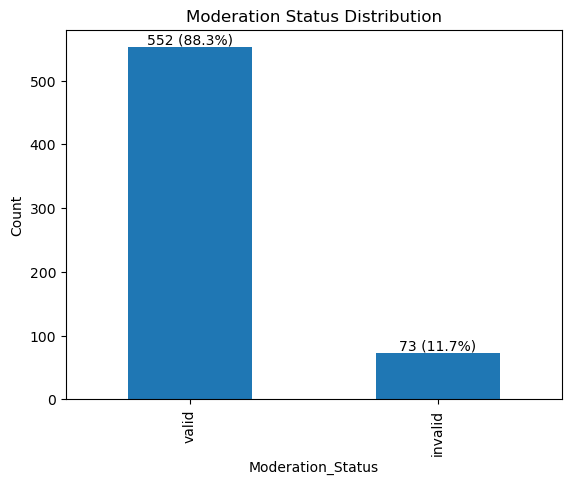

In [46]:
df = pd.read_csv('clean_objections.csv')
status_counts = df['Moderation_Status'].value_counts()
total = status_counts.sum()

ax = status_counts.plot(kind='bar')
labels = [f"{count} ({count/total:.1%})" for count in status_counts]
ax.bar_label(ax.containers[0], labels=labels)

plt.ylabel('Count')
plt.title('Moderation Status Distribution')
plt.show()